In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as ns

In [52]:
df = pd.read_csv('Advertising Budget and Sales.csv')

In [53]:
df.head()

,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [54]:
X = df[['TV Ad Budget ($)']]

In [55]:
y = df.iloc[:,-1]

In [56]:
X.isnull().sum()

TV Ad Budget ($)    0
dtype: int64

In [57]:
y.isnull().sum()

0

In [58]:
from sklearn.model_selection import train_test_split

In [59]:
X_train, X_test , y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state=0)

In [60]:
class Advertisement:
    def __init__(self):
        self.b = None
        self.m = None

    def fit(self, X_train, y_train):
        num = 0
        den = 0

        for i in range(X_train.shape[0]):
            X_train = np.asarray(X_train).reshape(-1)
            y_train = np.asarray(y_train)

            num = num + ((X_train[i] - X_train.mean())*(y_train[i] - y_train.mean()))
            den = den + ((X_train[i] - X_train.mean())*(X_train[i] - X_train.mean()))

        self.m = num / den
        self.b = y_train.mean() - (self.m * X_train.mean())
        print(self.m)
        print(self.b)

    def predict(self, X_test):
        predictions = []
        X_test = np.asarray(X_test).reshape(-1)

        for i in range(X_test.shape[0]):
            predictions.append(self.m * X_test[i] + self.b)
        return np.array(predictions)

In [61]:
lr = Advertisement()

In [62]:
lr.fit(X_train.values,y_train)

0.04600778960301719
7.292493773559359


In [63]:
lr.predict(X_test)

array([10.47623281,  9.59288325, 11.45159795, 20.62095042, 15.12301956,
        9.87813155,  7.69276154, 18.33896406,  8.38747917, 16.383633  ,
       19.3143292 , 11.30437303, 14.49731363, 15.93275666, 10.8074889 ,
       12.82263008, 19.51216269,  7.32469923, 10.72927566, 17.11055607,
       20.52433406, 13.74738665, 15.34845773, 13.35171966,  9.75391052,
       12.95605267, 14.91138373, 16.72409064, 17.59823864,  8.44728929,
       10.41182191, 16.44344313, 20.20688032, 18.41257652,  7.8997966 ,
        8.15283944, 10.03455803, 15.61070213, 10.43942658,  8.44268851])

In [64]:
from sklearn.linear_model import LinearRegression 

In [65]:
slr = LinearRegression()

In [71]:
type(y_train)

pandas.core.series.Series

In [69]:
slr.fit(X_train,y_train)

LinearRegression()

In [72]:
lr.predict(X_test)

array([10.47623281,  9.59288325, 11.45159795, 20.62095042, 15.12301956,
        9.87813155,  7.69276154, 18.33896406,  8.38747917, 16.383633  ,
       19.3143292 , 11.30437303, 14.49731363, 15.93275666, 10.8074889 ,
       12.82263008, 19.51216269,  7.32469923, 10.72927566, 17.11055607,
       20.52433406, 13.74738665, 15.34845773, 13.35171966,  9.75391052,
       12.95605267, 14.91138373, 16.72409064, 17.59823864,  8.44728929,
       10.41182191, 16.44344313, 20.20688032, 18.41257652,  7.8997966 ,
        8.15283944, 10.03455803, 15.61070213, 10.43942658,  8.44268851])

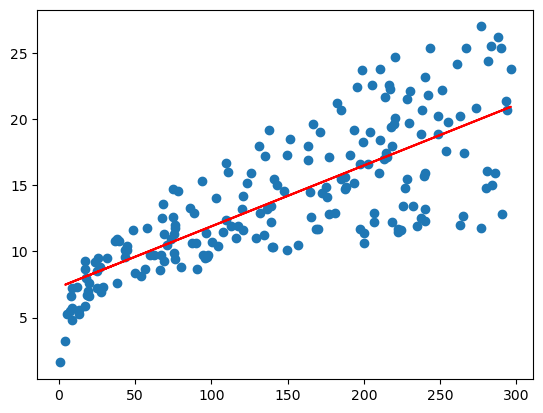

In [80]:
plt.scatter(df['TV Ad Budget ($)'], df['Sales ($)'])
plt.plot(X_train, slr.predict(X_train), color = 'red')